### Konteks / Skenario

Masih ingat platform e-commerce tempat kalian magang pada Tugas Mandiri Pertemuan 2? Bulan ini, tim engineering mengumumkan bahwa perusahaan mulai **bermigrasi ke infrastruktur Big Data** — seluruh data transaksi dari cabang-cabang di berbagai kota tidak lagi disimpan sebagai berkas CSV lepas di laptop analyst, melainkan akan disimpan secara terpusat di **HDFS**, sebagai fondasi sebelum diproses lebih lanjut menggunakan tools big data di pertemuan-pertemuan mendatang. Sebagai data analyst junior, kalian ditugaskan menjadi orang pertama yang mencoba alur kerja ini secara menyeluruh: dari data mentah di tiga kota berbeda, hingga tersimpan rapi di HDFS dan siap dianalisis kembali.

### Menyiapkan Dataset

Jalankan cell kode berikut **di dalam modul ini terlebih dahulu** untuk menghasilkan **tiga berkas CSV terpisah** (mensimulasikan data transaksi dari tiga cabang kota berbeda selama Agustus 2026).

In [4]:
# Sel ini menghasilkan TIGA dataset cabang (kota) terpisah untuk Tugas Mandiri Pertemuan 3
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)  # seed berbeda tiap kota agar datanya bervariasi, namun tetap konsisten/reproducible
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

print("\nKetiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris

Ketiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.


**A. Membangun Struktur Direktori HDFS**

In [5]:
# Membuat Direktori
!hdfs dfs -mkdir -p /user/asta/ecommerce/raw
!hdfs dfs -mkdir -p /user/asta/ecommerce/processed

# Menampilkan hasil
!hdfs dfs -ls -h /user/asta/ecommerce

Found 2 items
drwxr-xr-x   - asta supergroup          0 2026-09-08 16:34 /user/asta/ecommerce/processed
drwxr-xr-x   - asta supergroup          0 2026-09-08 15:43 /user/asta/ecommerce/raw


**B. Mengunggah Data Mentah ke HDFS**

In [6]:
# Mengunggah data Mentah ke HDFS
!hdfs dfs -put transaksi_magelang.csv /user/asta/ecommerce/raw
!hdfs dfs -put transaksi_yogyakarta.csv /user/asta/ecommerce/raw
!hdfs dfs -put transaksi_semarang.csv /user/asta/ecommerce/raw

# Menampilkan isi Direktori beserta ukurannya
!hdfs dfs -ls -h /user/asta/ecommerce/raw

put: `/user/asta/ecommerce/raw/transaksi_magelang.csv': File exists
put: `/user/asta/ecommerce/raw/transaksi_yogyakarta.csv': File exists
put: `/user/asta/ecommerce/raw/transaksi_semarang.csv': File exists
Found 3 items
-rw-r--r--   1 asta supergroup     12.0 K 2026-09-08 15:43 /user/asta/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 asta supergroup     11.9 K 2026-09-08 15:43 /user/asta/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 asta supergroup     12.4 K 2026-09-08 15:43 /user/asta/ecommerce/raw/transaksi_yogyakarta.csv


**C. Membaca Kembali dan Menggabungkan Data dari HDFS**

In [7]:
from hdfs import InsecureClient
import pandas as pd
import io

client = InsecureClient('http://localhost:9870', user='asta')

kota_list = ['magelang', 'yogyakarta', 'semarang']
list_df = []

# Saya Disini Menggunakan Perulangan Untuk Memanggil Data Tiap Kotanya
for kota in kota_list:
    path_hdfs = f'/user/asta/ecommerce/raw/transaksi_{kota}.csv'
    with client.read(path_hdfs, encoding='utf-8') as reader:
        isi = reader.read()
    df_temp = pd.read_csv(io.StringIO(isi))
    list_df.append(df_temp)

# Menggabungkan DataFrame
df_gabungan = pd.concat(list_df, ignore_index=True)

# Total Data Gabungan
display(df_gabungan.sample(10))
print(df_gabungan['kota'].value_counts())

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
397,YOG-2197,2026-08-27,Makanan & Minuman,4,25000,Kartu Kredit,Yogyakarta
54,MAG-2054,2026-08-25,Rumah Tangga,4,250000,Transfer Bank,Magelang
36,MAG-2036,2026-08-11,Elektronik,2,100000,Kartu Kredit,Magelang
267,YOG-2067,2026-08-15,Rumah Tangga,5,150000,E-Wallet,Yogyakarta
78,MAG-2078,2026-08-05,Elektronik,7,25000,E-Wallet,Magelang
406,SEM-2006,2026-08-13,Fashion,1,100000,Kartu Kredit,Semarang
360,YOG-2160,2026-08-15,Rumah Tangga,7,250000,Transfer Bank,Yogyakarta
18,MAG-2018,2026-08-13,Fashion,6,150000,Kartu Kredit,Magelang
202,YOG-2002,2026-08-29,Rumah Tangga,4,100000,E-Wallet,Yogyakarta
117,MAG-2117,2026-08-20,Rumah Tangga,3,50000,COD,Magelang


kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


**D. Mengolah dan Mendownload Hasil ke Direktori**

In [17]:
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']
df_gabungan

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota,total_pendapatan
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang,50000
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang,175000
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang,175000
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang,150000
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang,700000
...,...,...,...,...,...,...,...,...
595,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang,450000
596,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang,375000
597,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang,300000
598,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang,175000


In [18]:
df_ringkasan = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()
df_ringkasan

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000


In [19]:
df_gabungan.to_csv('data_gabungan_bersih.csv', index=False)
df_ringkasan.to_csv('ringkasan_kota_kategori.csv', index=False)

!hdfs dfs -put -f data_gabungan_bersih.csv /user/asta/ecommerce/processed/
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/asta/ecommerce/processed/

!hdfs dfs -ls /user/asta/ecommerce/processed/

Found 2 items
-rw-r--r--   1 asta supergroup      41257 2026-09-09 10:36 /user/asta/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 asta supergroup        530 2026-09-09 10:36 /user/asta/ecommerce/processed/ringkasan_kota_kategori.csv


**E. Dokumentasi dan Refleksi**

**Struktur Folder**

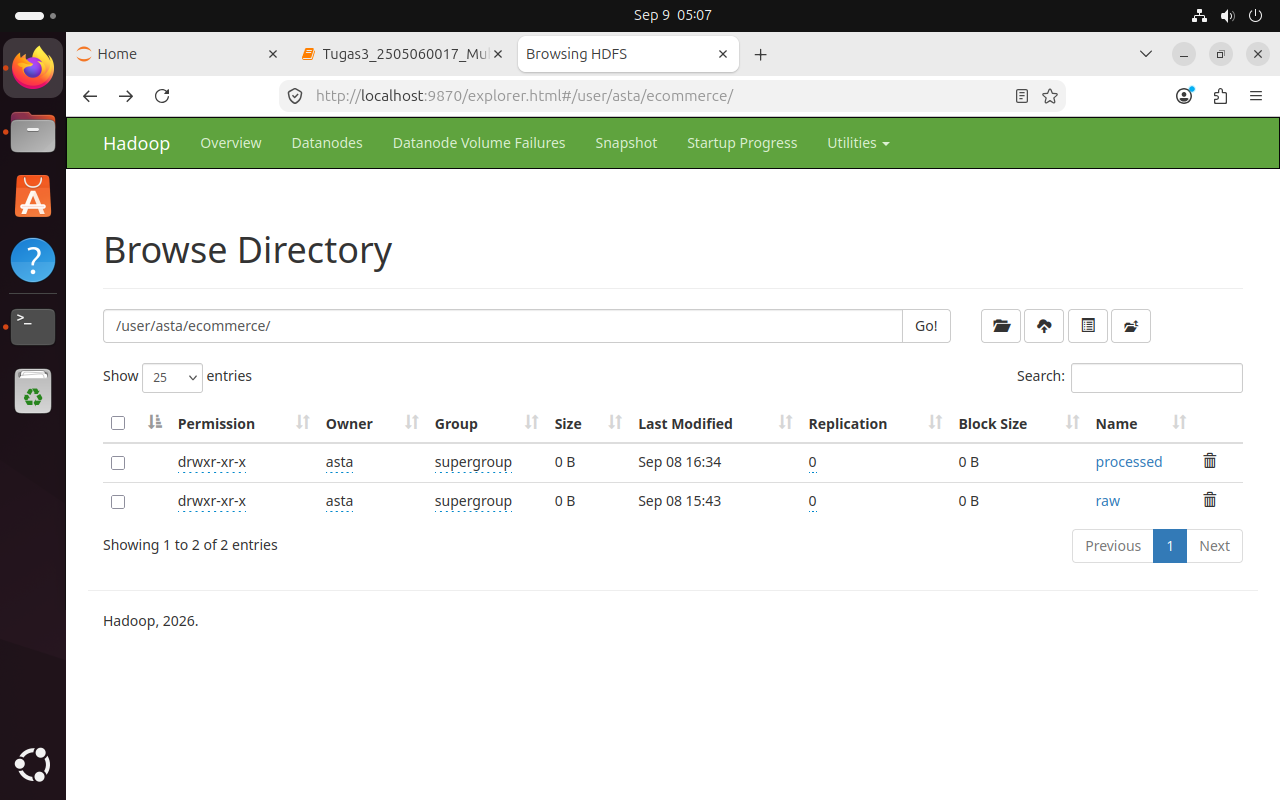

**Isi Folder RAW**

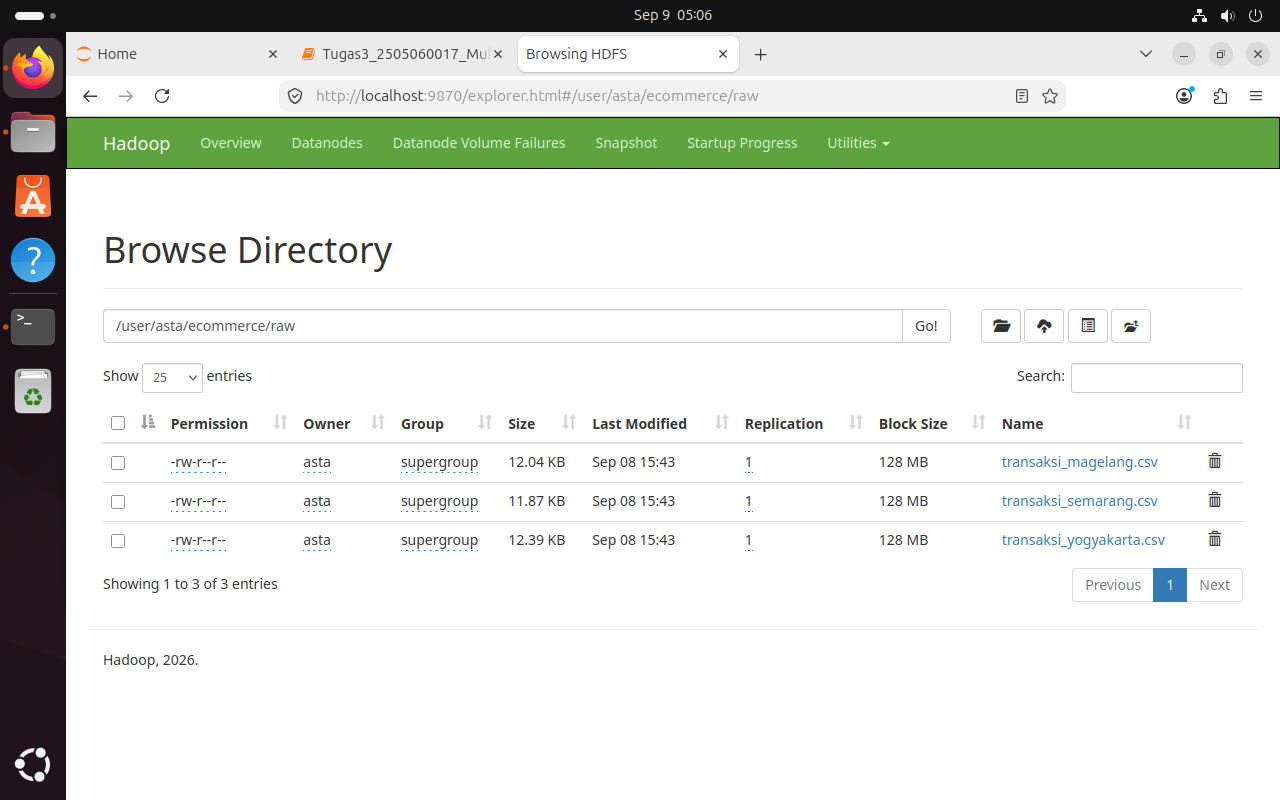

**Isi Folder Processed**

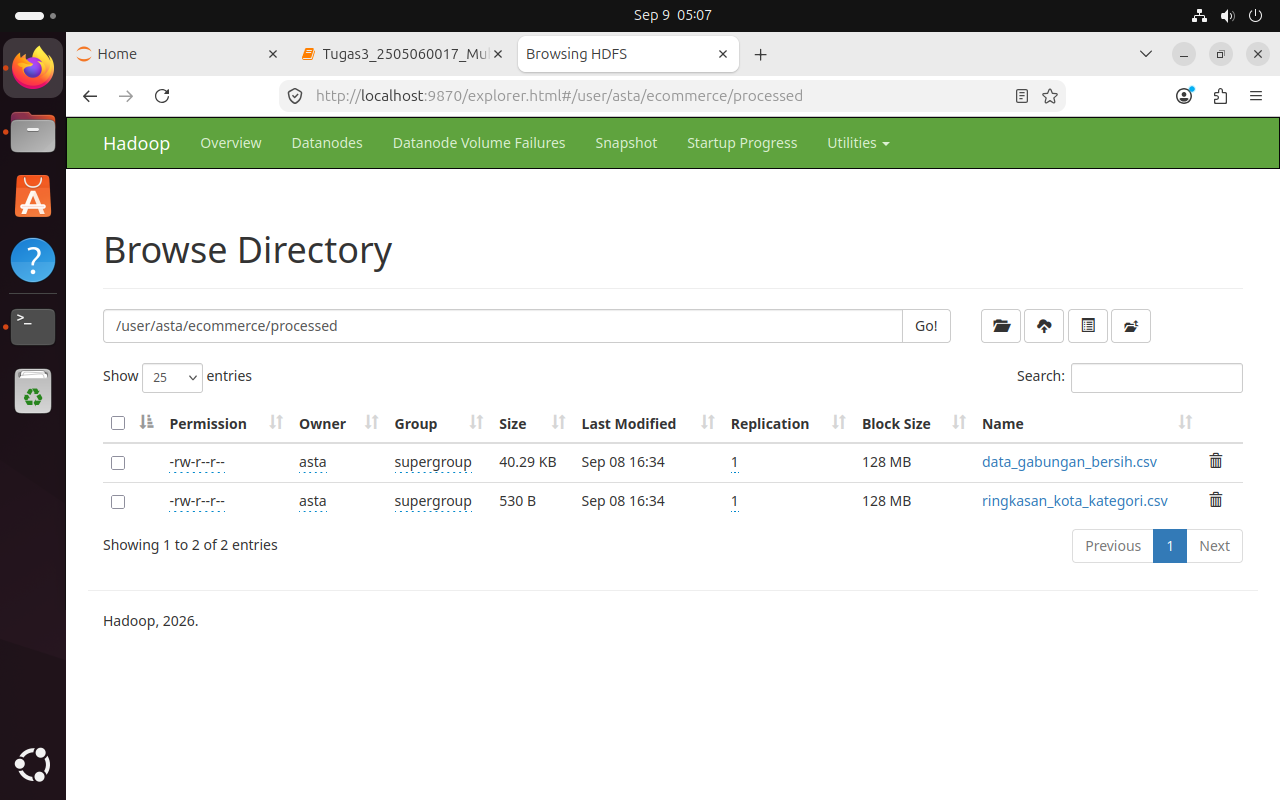

**Refleksi**


Keuntungan pemisahan data mentah dari data olahan salah satunya adalah kita jadi bisa membedakan mana data asli yang belum diproses dan mana data yang sudah diolah. Tidak semua pihak hanya membutuhkan data yang telah diproses, bagi sebagian orang data mentah tetap penting untuk analisis mereka sendiri, misal jika mereka ingin melakukan perhitungan atau pengelompokan yang berbeda dari yang sudah dilakukan. Jika data mentah dan olahan digabung dalam satu folder, ada risiko data asli tertimpa atau berubah secara tidak sengaja saat proses pengolahan berlangsung, sehingga keaslian data bisa hilang. Selain itu, pemisahan folder raw dan processed juga memudahkan penelusuran jika terjadi kesalahan pada hasil akhir, kita bisa mengecek apakah kesalahan berasal dari data mentah atau dari proses pengolahannya, tanpa harus bingung mencari-cari di antara file yang tercampur. Dari sisi keamanan, data mentah yang berisi detail transaksi individual aksesnya lebih ketat dibandingkan data olahan yang sudah diringkas dan lebih aman untuk dibagikan ke pihak lain. Dengan struktur folder yang terpisah ini alur kerja pengolahan data menjadi lebih rapi, aman, dan mudah ditelusuri kapan pun saat diperlukan.

**Eksplorasi**

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

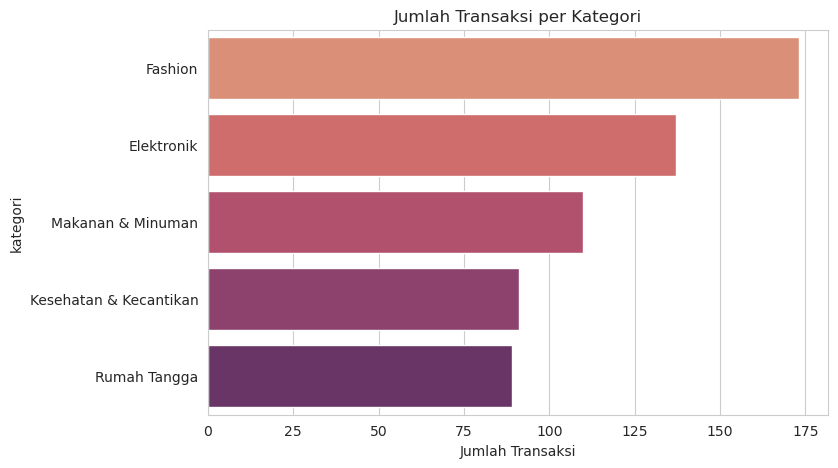

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=kategori_terlaris.values, 
    y=kategori_terlaris.index, 
    hue=kategori_terlaris.index,   
    palette="flare",
    legend=False                    
)
plt.title("Jumlah Transaksi per Kategori")
plt.xlabel("Jumlah Transaksi")
plt.show()

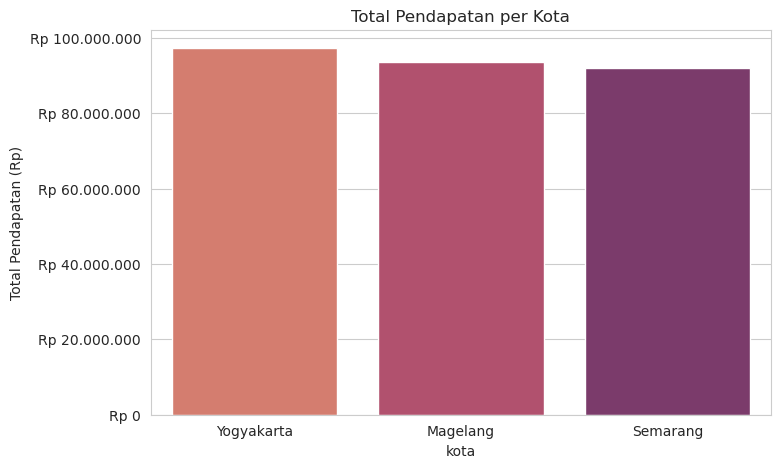

In [23]:
import matplotlib.ticker as mticker

plt.figure(figsize=(8,5))
sns.barplot(x=pendapatan_per_kota.index, y=pendapatan_per_kota.values, hue=pendapatan_per_kota.index, palette="flare", legend=False)
plt.title("Total Pendapatan per Kota")
plt.ylabel("Total Pendapatan (Rp)")

ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:,.0f}'.replace(',', '.')))

plt.show()